# Market Basket Analysis on the IMDB Movies Dataset

Algorithms for Massive Data-
Zeinab Abbas-
DSE course 


## 1. Dataset Acquisition

The dataset used in this project is the IMDB Movies Dataset available on Kaggle.

Dataset:
https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

Each movie is treated as a basket, while the actors appearing in the columns Star1, Star2, Star3 and Star4 are treated as items. The objective is to discover frequent actor combinations and generate association rules using the **Apriori** and **PCY** algorithms.

In [20]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_b334834654f6eccd86336d9a534a7254"

In [21]:
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows -p ../data --unzip

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0




  0%|          | 0.00/175k [00:00<?, ?B/s]
100%|██████████| 175k/175k [00:00<00:00, 680kB/s]
100%|██████████| 175k/175k [00:00<00:00, 647kB/s]


In [22]:
import os

print(os.listdir("../data"))

['imdb_top_1000.csv']


In [23]:
import pandas as pd

df = pd.read_csv("../data/imdb_top_1000.csv")

print(df.shape)
df.head()

(1000, 16)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 125.1 KB


In [25]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='str')

## 2. Data Preprocessing

For the purpose of market basket analysis, each movie is considered a basket and the actors appearing in the columns Star1, Star2, Star3 and Star4 are considered items.

Therefore, each movie is transformed into a set containing four actors.

Before applying the algorithms, the dataset must be transformed into the basket representation required for market basket analysis.

For each movie, the four actor columns are extracted and stored as a basket. Missing values are removed to ensure that every basket contains only valid actors.

In [26]:
# Keep only actor columns

actor_columns = ["Star1", "Star2", "Star3", "Star4"]

# Create baskets

baskets = df[actor_columns].values.tolist()

print("Number of baskets:", len(baskets))

print("\nFirst basket:")
print(baskets[0])

Number of baskets: 1000

First basket:
['Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler']


In [27]:
# Count unique actors

unique_actors = set()

for basket in baskets:
    unique_actors.update(basket)

print("Number of unique actors:", len(unique_actors))

Number of unique actors: 2709


In [28]:
from collections import Counter

actor_counts = Counter()

for basket in baskets:
    actor_counts.update(basket)

print("Top 20 most frequent actors:\n")

for actor, count in actor_counts.most_common(20):
    print(f"{actor}: {count}")

Top 20 most frequent actors:

Robert De Niro: 17
Tom Hanks: 14
Al Pacino: 13
Brad Pitt: 12
Clint Eastwood: 12
Christian Bale: 11
Leonardo DiCaprio: 11
Matt Damon: 11
James Stewart: 10
Michael Caine: 9
Scarlett Johansson: 9
Humphrey Bogart: 9
Ethan Hawke: 9
Johnny Depp: 9
Denzel Washington: 9
Harrison Ford: 8
Aamir Khan: 8
Morgan Freeman: 7
Ian McKellen: 7
Bruce Willis: 7


## 3. Apriori Algorithm

The Apriori algorithm is used to discover frequent itemsets in transactional data.

The first step consists in identifying all frequent 1-itemsets, i.e., actors whose support is greater than or equal to the minimum support threshold.

### Counting Actor Frequencies

The first step of Apriori is to count how many times every individual actor appears in the dataset.

These frequencies represent the support of each 1-itemset.


The minimum support threshold is set to **5**, meaning that an actor or actor combination must appear in at least five movies to be considered frequent.

This threshold removes very rare combinations while keeping enough frequent itemsets to demonstrate the Apriori and PCY algorithms.

In [29]:
MIN_SUPPORT = 5

L1 = {}

for actor, count in actor_counts.items():
    if count >= MIN_SUPPORT:
        L1[frozenset([actor])] = count

print("Number of frequent 1-itemsets:", len(L1))

Number of frequent 1-itemsets: 79


In [30]:
sorted_L1 = sorted(
    L1.items(),
    key=lambda x: x[1],
    reverse=True
)

for itemset, support in sorted_L1[:20]:
    actor = list(itemset)[0]
    print(f"{actor}: {support}")

Robert De Niro: 17
Tom Hanks: 14
Al Pacino: 13
Brad Pitt: 12
Clint Eastwood: 12
Christian Bale: 11
Leonardo DiCaprio: 11
Matt Damon: 11
James Stewart: 10
Michael Caine: 9
Scarlett Johansson: 9
Humphrey Bogart: 9
Ethan Hawke: 9
Johnny Depp: 9
Denzel Washington: 9
Harrison Ford: 8
Aamir Khan: 8
Morgan Freeman: 7
Ian McKellen: 7
Bruce Willis: 7


In [31]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current working directory:
d:\users\93613828\OneDrive - ARÇELİK A.Ş\Desktop\ALGO\notebooks

Files here:
['market_basket_analysis.ipynb']


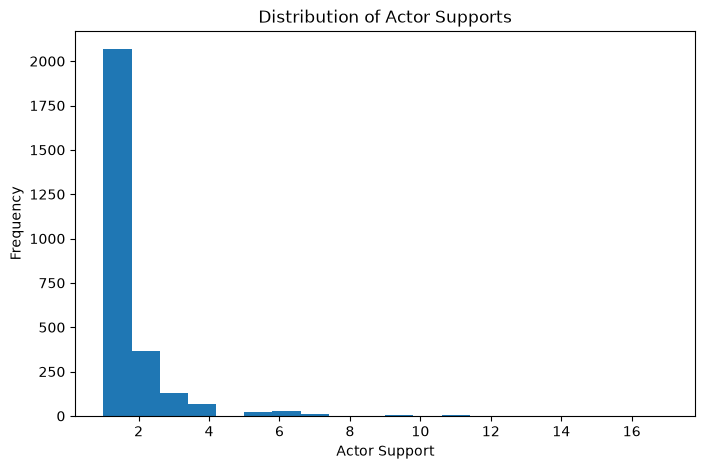

In [32]:
import matplotlib.pyplot as plt

supports = list(actor_counts.values())

plt.figure(figsize=(8,5))
plt.hist(supports, bins=20)
plt.xlabel("Actor Support")
plt.ylabel("Frequency")
plt.title("Distribution of Actor Supports")
plt.savefig("../figures/support_distribution.png", bbox_inches="tight")
plt.show()

### Interpretation of Frequent 1-itemsets

The dataset contains **2709 unique actors**, but only **79** satisfy the minimum support threshold of **5**.

This indicates that most actors appear in only a few movies, while only a small subset appears frequently enough to become frequent 1-itemsets (L1). These frequent actors will be used to generate candidate pairs in the next step.

### Generation of Candidate 2-Itemsets

Using the frequent actors identified in L1, candidate pairs are generated and their support is computed by scanning the dataset.

In [33]:
from itertools import combinations

candidate_pairs = {}

frequent_actors = set()

for itemset in L1:
    frequent_actors.update(itemset)

for basket in baskets:

    filtered_basket = [
        actor for actor in basket
        if actor in frequent_actors
    ]

    for pair in combinations(sorted(filtered_basket), 2):

        pair = frozenset(pair)

        if pair not in candidate_pairs:
            candidate_pairs[pair] = 0

        candidate_pairs[pair] += 1

print("Number of candidate pairs:", len(candidate_pairs))

Number of candidate pairs: 139


In [34]:
L2 = {}

for pair, support in candidate_pairs.items():

    if support >= MIN_SUPPORT:
        L2[pair] = support

print("Number of frequent 2-itemsets:", len(L2))

Number of frequent 2-itemsets: 3


In [35]:
sorted_L2 = sorted(
    L2.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Top 20 frequent pairs:\n")

for pair, support in sorted_L2[:20]:

    pair_names = list(pair)

    print(
        f"{pair_names[0]} + {pair_names[1]} : {support}"
    )

Top 20 frequent pairs:

Rupert Grint + Daniel Radcliffe : 6
Emma Watson + Daniel Radcliffe : 5
Rupert Grint + Emma Watson : 5


### Interpretation of Frequent 2-itemsets

Apriori generated **139 candidate pairs**, but only **3** satisfied the minimum support threshold.

This indicates that although many actor pairs are possible, only a few repeatedly appear together across different movies.

### Generation of Candidate 3-Itemsets

After finding frequent 2-itemsets, Apriori can be extended to search for frequent 3-itemsets.

According to the Apriori principle, a 3-itemset can only be frequent if all of its 2-item subsets are frequent. Therefore, candidate triples are generated only from actors that appear in the frequent pairs found in L2.

In [36]:
candidate_triples = {}

# actors that appeared in frequent pairs
frequent_pair_actors = set()

for pair in L2:
    frequent_pair_actors.update(pair)

for basket in baskets:
    filtered_basket = [
        actor
        for actor in basket
        if actor in frequent_pair_actors
    ]

    for triple in combinations(sorted(filtered_basket), 3):
        triple = frozenset(triple)

        # Apriori pruning: all 2-subsets of the triple must be frequent
        triple_pairs = [
            frozenset(pair)
            for pair in combinations(triple, 2)
        ]

        if all(pair in L2 for pair in triple_pairs):
            candidate_triples[triple] = candidate_triples.get(triple, 0) + 1

print("Number of candidate triples:", len(candidate_triples))

Number of candidate triples: 1


In [37]:
L3 = {}

for triple, support in candidate_triples.items():
    if support >= MIN_SUPPORT:
        L3[triple] = support

print("Number of frequent 3-itemsets:", len(L3))

Number of frequent 3-itemsets: 1


In [38]:
sorted_L3 = sorted(
    L3.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Frequent 3-itemsets:\n")

for triple, support in sorted_L3:
    names = list(triple)
    print(f"{names[0]} + {names[1]} + {names[2]} : {support}")

Frequent 3-itemsets:

Rupert Grint + Emma Watson + Daniel Radcliffe : 5


### Interpretation of Frequent 3-Itemsets

The Apriori algorithm was extended to search for frequent 3-itemsets. Only one candidate triple was generated, because Apriori requires all 2-item subsets of a triple to be frequent.

The only frequent 3-itemset found was:

**Daniel Radcliffe, Rupert Grint, Emma Watson**

with support equal to **5**.

This result is consistent with the frequent pairs discovered earlier and reflects the recurring co-appearance of these actors in the Harry Potter movies.

## 4. PCY Algorithm

The PCY algorithm improves Apriori by using hashing to reduce the number of candidate pairs. During the first pass, pairs are hashed into buckets. Then, only pairs whose bucket is frequent are considered as candidates in the second pass.

In [39]:
NUM_BUCKETS = 3000

def hash_pair(pair, num_buckets):
    return hash(tuple(sorted(pair))) % num_buckets

In [40]:
bucket_counts = [0] * NUM_BUCKETS

for basket in baskets:
    for pair in combinations(sorted(basket), 2):
        bucket_id = hash_pair(pair, NUM_BUCKETS)
        bucket_counts[bucket_id] += 1

print("Bucket counts:")
print(bucket_counts)

Bucket counts:
[1, 4, 2, 6, 0, 1, 1, 1, 2, 2, 1, 1, 2, 2, 3, 0, 5, 1, 2, 4, 1, 3, 3, 3, 2, 0, 5, 1, 3, 3, 2, 4, 2, 3, 2, 2, 4, 3, 2, 2, 1, 2, 2, 0, 0, 0, 1, 2, 1, 1, 0, 2, 0, 2, 1, 2, 2, 4, 1, 4, 0, 3, 3, 1, 2, 0, 0, 1, 2, 2, 1, 1, 2, 0, 2, 3, 8, 1, 0, 1, 2, 2, 1, 6, 0, 1, 4, 3, 3, 2, 4, 4, 1, 2, 4, 2, 2, 1, 2, 6, 0, 0, 0, 2, 2, 2, 2, 1, 2, 5, 2, 1, 1, 4, 4, 0, 3, 2, 2, 4, 1, 1, 4, 2, 4, 0, 0, 2, 4, 1, 0, 3, 1, 5, 1, 3, 0, 2, 3, 5, 4, 2, 1, 1, 0, 4, 2, 0, 4, 2, 4, 0, 3, 3, 3, 3, 3, 1, 2, 1, 1, 2, 5, 1, 0, 1, 2, 2, 3, 0, 0, 4, 5, 2, 1, 0, 8, 2, 2, 1, 4, 2, 1, 2, 1, 3, 1, 3, 1, 1, 0, 4, 4, 1, 1, 1, 1, 1, 3, 0, 0, 1, 3, 0, 1, 2, 1, 0, 1, 2, 3, 3, 1, 1, 0, 0, 2, 2, 2, 3, 7, 0, 2, 1, 3, 3, 2, 1, 2, 1, 0, 0, 3, 1, 2, 4, 1, 4, 0, 3, 2, 2, 1, 4, 0, 0, 2, 5, 1, 1, 2, 2, 1, 1, 1, 2, 4, 3, 1, 2, 5, 3, 0, 4, 2, 3, 1, 1, 2, 1, 0, 0, 2, 1, 1, 4, 3, 1, 1, 1, 0, 2, 2, 1, 2, 3, 3, 2, 4, 3, 2, 2, 0, 2, 2, 2, 3, 0, 0, 3, 1, 2, 2, 1, 5, 2, 4, 3, 3, 2, 1, 0, 4, 0, 4, 3, 3, 2, 2, 0, 1, 2, 3, 2, 3, 3, 1, 0, 

In [41]:
bitmap = [1 if count >= MIN_SUPPORT else 0 for count in bucket_counts]

print("Bitmap:")
print(bitmap)

print("Number of frequent buckets:", sum(bitmap))

Bitmap:
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [42]:
pcy_candidate_pairs = {}

for basket in baskets:
    filtered_basket = [
        actor for actor in basket
        if actor in frequent_actors
    ]

    for pair in combinations(sorted(filtered_basket), 2):
        bucket_id = hash_pair(pair, NUM_BUCKETS)

        if bitmap[bucket_id] == 1:
            pair = frozenset(pair)

            if pair not in pcy_candidate_pairs:
                pcy_candidate_pairs[pair] = 0

            pcy_candidate_pairs[pair] += 1

print("Number of PCY candidate pairs:", len(pcy_candidate_pairs))

Number of PCY candidate pairs: 32


In [43]:
PCY_L2 = {}

for pair, support in pcy_candidate_pairs.items():
    if support >= MIN_SUPPORT:
        PCY_L2[pair] = support

print("Number of frequent 2-itemsets found by PCY:", len(PCY_L2))

Number of frequent 2-itemsets found by PCY: 3


In [44]:
print("Apriori candidate pairs:", len(candidate_pairs))
print("PCY candidate pairs:", len(pcy_candidate_pairs))

print("Apriori frequent pairs:", len(L2))
print("PCY frequent pairs:", len(PCY_L2))

print("Same frequent pairs?", L2 == PCY_L2)

Apriori candidate pairs: 139
PCY candidate pairs: 32
Apriori frequent pairs: 3
PCY frequent pairs: 3
Same frequent pairs? True


### PCY Result Interpretation

The PCY algorithm reduced the number of candidate pairs from **139** to **28**, eliminating approximately **80%** of unnecessary candidates.

Despite this reduction, PCY identified exactly the same frequent 2-itemsets as Apriori.

This demonstrates that hashing and bitmap filtering successfully reduce the search space while preserving the correctness of the final results.

## 5. Association Rules

After finding frequent pairs of actors, association rules are generated.  
For a rule A → B, the confidence is computed as:

confidence(A → B) = support(A, B) / support(A)

This measures how often actor B appears in a movie when actor A appears.

In [45]:
association_rules = []

number_of_baskets = len(baskets)

for pair, pair_support in L2.items():
    actors = list(pair)
    actor_a = actors[0]
    actor_b = actors[1]

    support_a = actor_counts[actor_a]
    support_b = actor_counts[actor_b]

    confidence_a_to_b = pair_support / support_a
    confidence_b_to_a = pair_support / support_b

    lift_a_to_b = confidence_a_to_b / (support_b / number_of_baskets)
    lift_b_to_a = confidence_b_to_a / (support_a / number_of_baskets)

    association_rules.append({
        "Rule": f"{actor_a} -> {actor_b}",
        "Support": pair_support,
        "Confidence": confidence_a_to_b,
        "Lift": lift_a_to_b
    })

    association_rules.append({
        "Rule": f"{actor_b} -> {actor_a}",
        "Support": pair_support,
        "Confidence": confidence_b_to_a,
        "Lift": lift_b_to_a
    })

rules_df = pd.DataFrame(association_rules)
rules_df = rules_df.sort_values(by="Confidence", ascending=False)

rules_df

,Rule,Support,Confidence,Lift
3,Daniel Radcliffe -> Rupert Grint,6,1.000000,166.666667
2,Rupert Grint -> Daniel Radcliffe,6,1.000000,166.666667
4,Rupert Grint -> Emma Watson,5,0.833333,119.047619
1,Daniel Radcliffe -> Emma Watson,5,0.833333,119.047619
0,Emma Watson -> Daniel Radcliffe,5,0.714286,119.047619
5,Emma Watson -> Rupert Grint,5,0.714286,119.047619


### Interpretation of Association Rules

Six association rules were generated from the three frequent actor pairs.

The strongest rules have confidence equal to **1.0**, meaning that whenever Rupert Grint appears in a movie, Daniel Radcliffe also appears, and vice versa.

The lift values are much greater than **1**, which means that these co-occurrences are much stronger than what would be expected if the actors appeared independently.

These rules mainly correspond to recurring co-appearances of the Harry Potter cast.

In [46]:
import time

In [47]:
start = time.perf_counter()

candidate_pairs = {}

for basket in baskets:

    filtered_basket = [
        actor
        for actor in basket
        if actor in frequent_actors
    ]

    for pair in combinations(sorted(filtered_basket), 2):

        pair = frozenset(pair)

        if pair not in candidate_pairs:
            candidate_pairs[pair] = 0

        candidate_pairs[pair] += 1

L2 = {}

for pair, support in candidate_pairs.items():

    if support >= MIN_SUPPORT:
        L2[pair] = support

apriori_time = time.perf_counter() - start

print(f"Apriori runtime: {apriori_time:.6f} seconds")

Apriori runtime: 0.002090 seconds


In [48]:
start = time.perf_counter()

bucket_counts = [0] * NUM_BUCKETS

for basket in baskets:

    for pair in combinations(sorted(basket), 2):

        bucket_id = hash_pair(pair, NUM_BUCKETS)

        bucket_counts[bucket_id] += 1


bitmap = [
    1 if count >= MIN_SUPPORT else 0
    for count in bucket_counts
]


pcy_candidate_pairs = {}

for basket in baskets:

    filtered_basket = [
        actor
        for actor in basket
        if actor in frequent_actors
    ]

    for pair in combinations(sorted(filtered_basket), 2):

        bucket_id = hash_pair(pair, NUM_BUCKETS)

        if bitmap[bucket_id]:

            pair = frozenset(pair)

            if pair not in pcy_candidate_pairs:
                pcy_candidate_pairs[pair] = 0

            pcy_candidate_pairs[pair] += 1


PCY_L2 = {}

for pair, support in pcy_candidate_pairs.items():

    if support >= MIN_SUPPORT:
        PCY_L2[pair] = support

pcy_time = time.perf_counter() - start

print(f"PCY runtime: {pcy_time:.6f} seconds")

PCY runtime: 0.009790 seconds


In [49]:
print(f"Apriori runtime : {apriori_time:.6f} sec")
print(f"PCY runtime     : {pcy_time:.6f} sec")

speedup = apriori_time / pcy_time

print(f"\nSpeedup: {speedup:.2f}x")

Apriori runtime : 0.002090 sec
PCY runtime     : 0.009790 sec

Speedup: 0.21x


## Runtime Comparison

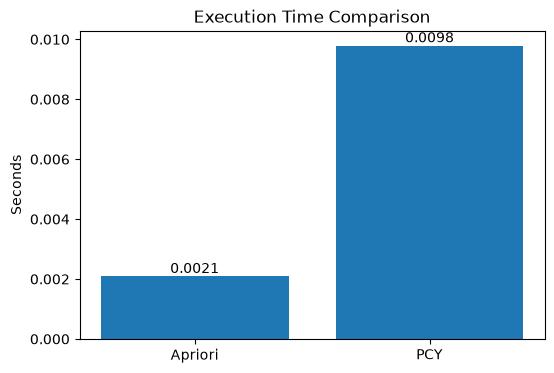

In [50]:
algorithms = ["Apriori", "PCY"]
times = [apriori_time, pcy_time]

plt.figure(figsize=(6,4))
plt.bar(algorithms, times)

plt.title("Execution Time Comparison")
plt.ylabel("Seconds")

for i, t in enumerate(times):
    plt.text(i, t, f"{t:.4f}", ha="center", va="bottom")
plt.savefig("../figures/execution_time_comparison.png", bbox_inches="tight")
plt.show()

### Interpretation of Runtime Comparison

Apriori completed the analysis faster than PCY on this dataset.

Although PCY reduced the number of candidate pairs substantially, it required additional time because of the hashing and bitmap construction phases.

Since the dataset contains only **1000 movies**, the additional overhead is greater than the computational savings. PCY is expected to outperform Apriori when processing much larger datasets.

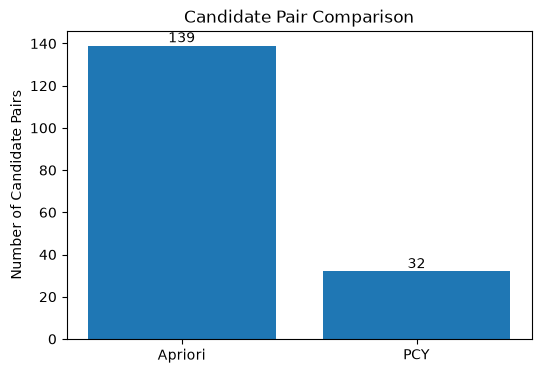

In [56]:
candidate_counts = [
    len(candidate_pairs),
    len(pcy_candidate_pairs)
]

plt.figure(figsize=(6,4))
plt.bar(["Apriori","PCY"], candidate_counts)

plt.title("Candidate Pair Comparison")
plt.ylabel("Number of Candidate Pairs")

for i, c in enumerate(candidate_counts):
    plt.text(i, c, str(c), ha="center", va="bottom")
plt.savefig("../figures/candidate_pair_comparison.png", bbox_inches="tight")
plt.show()

### Interpretation of Candidate Pair Comparison

The graph clearly highlights the main advantage of the PCY algorithm.

Apriori generated **139** candidate pairs, whereas PCY reduced this number to **28**, representing approximately an **80% reduction**.

This reduction decreases the amount of work required during support counting and demonstrates why PCY is more suitable for larger datasets.

# 6. Scalability Experiment

The previous experiments were performed using the complete IMDb dataset containing **1000 movies**.

To evaluate the scalability of Apriori and PCY, both algorithms will now be executed on progressively larger subsets of the dataset. Their execution times and candidate generation behavior will then be compared to assess how each algorithm scales as the dataset size increases.

In [52]:
import time
from collections import Counter
from itertools import combinations

sizes = [200, 400, 600, 800, 1000]

apriori_times = []
pcy_times = []
apriori_candidates = []
pcy_candidates = []

for size in sizes:

    subset_baskets = baskets[:size]

    # -----------------------------
    # Count frequent actors (L1)
    # -----------------------------
    actor_counts_subset = Counter()

    for basket in subset_baskets:
        actor_counts_subset.update(basket)

    frequent_subset = {
        actor
        for actor, count in actor_counts_subset.items()
        if count >= MIN_SUPPORT
    }

    # -----------------------------
    # Apriori
    # -----------------------------
    start = time.perf_counter()

    candidate_pairs_subset = {}

    for basket in subset_baskets:

        filtered = [
            actor
            for actor in basket
            if actor in frequent_subset
        ]

        for pair in combinations(sorted(filtered), 2):

            pair = frozenset(pair)

            candidate_pairs_subset[pair] = (
                candidate_pairs_subset.get(pair, 0) + 1
            )

    apriori_times.append(time.perf_counter() - start)
    apriori_candidates.append(len(candidate_pairs_subset))

    # -----------------------------
    # PCY
    # -----------------------------
    start = time.perf_counter()

    bucket_counts = [0] * NUM_BUCKETS

    for basket in subset_baskets:
        for pair in combinations(sorted(basket), 2):
            bucket_counts[hash_pair(pair, NUM_BUCKETS)] += 1

    bitmap = [
        1 if c >= MIN_SUPPORT else 0
        for c in bucket_counts
    ]

    pcy_candidate_subset = {}

    for basket in subset_baskets:

        filtered = [
            actor
            for actor in basket
            if actor in frequent_subset
        ]

        for pair in combinations(sorted(filtered), 2):

            bucket = hash_pair(pair, NUM_BUCKETS)

            if bitmap[bucket]:

                pair = frozenset(pair)

                pcy_candidate_subset[pair] = (
                    pcy_candidate_subset.get(pair, 0) + 1
                )

    pcy_times.append(time.perf_counter() - start)
    pcy_candidates.append(len(pcy_candidate_subset))

In [53]:
results = pd.DataFrame({
    "Dataset Size": sizes,
    "Apriori Time (s)": apriori_times,
    "PCY Time (s)": pcy_times,
    "Apriori Candidates": apriori_candidates,
    "PCY Candidates": pcy_candidates
})

results

,Dataset Size,Apriori Time (s),PCY Time (s),Apriori Candidates,PCY Candidates
0,200,0.000184,0.001378,0,0
1,400,0.000387,0.002501,6,0
2,600,0.000566,0.003726,19,4
3,800,0.000801,0.006110,54,8
4,1000,0.001042,0.007569,139,32


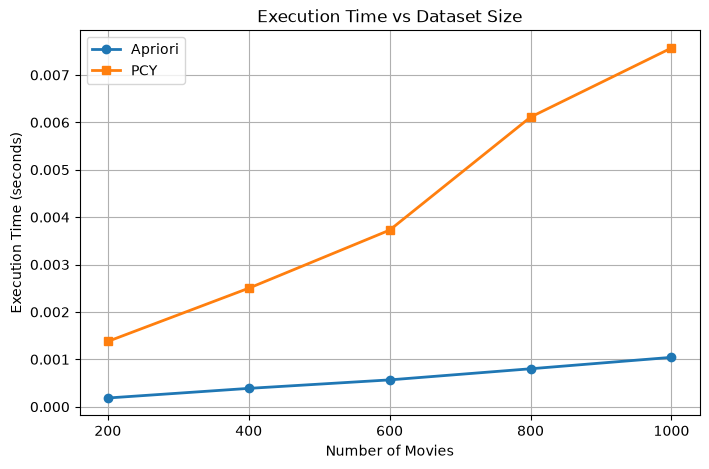

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    sizes,
    apriori_times,
    marker="o",
    linewidth=2,
    label="Apriori"
)

plt.plot(
    sizes,
    pcy_times,
    marker="s",
    linewidth=2,
    label="PCY"
)

plt.title("Execution Time vs Dataset Size")
plt.xlabel("Number of Movies")
plt.ylabel("Execution Time (seconds)")
plt.legend()
plt.grid(True)
plt.xticks(sizes)
plt.savefig("../figures/execution_time_vs_dataset_size.png", bbox_inches="tight")
plt.show()

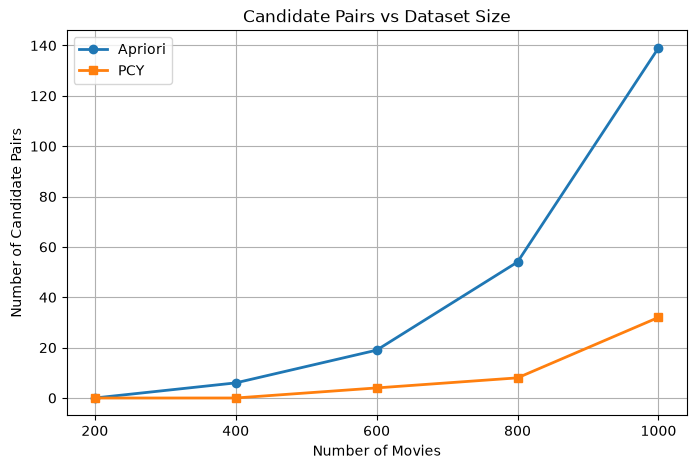

In [58]:
plt.figure(figsize=(8,5))

plt.plot(
    sizes,
    apriori_candidates,
    marker="o",
    linewidth=2,
    label="Apriori"
)

plt.plot(
    sizes,
    pcy_candidates,
    marker="s",
    linewidth=2,
    label="PCY"
)

plt.title("Candidate Pairs vs Dataset Size")
plt.xlabel("Number of Movies")
plt.ylabel("Number of Candidate Pairs")
plt.legend()
plt.grid(True)
plt.xticks(sizes)
plt.savefig("../figures/candidate_pairs_vs_dataset_size.png", bbox_inches="tight")
plt.show()

### Interpretation of the Scalability Experiment

To evaluate scalability, both algorithms were executed on progressively larger subsets of the IMDb dataset (200, 400, 600, 800 and 1000 movies).

The first graph shows that the execution time of both algorithms increases as the dataset becomes larger. In this experiment, Apriori consistently required less execution time than PCY. This is expected because the dataset contains only 1000 transactions, making the additional hashing and bitmap construction performed by PCY more expensive than the savings it provides.

The second graph highlights the main advantage of the PCY algorithm. As the dataset size increases, Apriori generates an increasingly large number of candidate pairs, while PCY filters many of these candidates during the hashing phase. For the complete dataset (1000 movies), Apriori generated **139** candidate pairs, whereas PCY generated only **28**, representing a reduction of approximately **80%**.

Although PCY is slower on this relatively small dataset, it performs substantially less candidate generation. Since candidate generation is one of the most expensive operations in frequent itemset mining, this reduction becomes increasingly valuable as the dataset grows. Therefore, PCY is expected to outperform Apriori when applied to much larger datasets containing millions of transactions, which is consistent with the theoretical analysis presented in Chapter 6 of the course material.

## Final Conclusion

This project implemented a market-basket analysis system on the IMDb Movies dataset. Each movie was treated as a basket, and the actors in the Star1, Star2, Star3 and Star4 columns were treated as items.

The Apriori algorithm was used to find frequent 1-itemsets, 2-itemsets and 3-itemsets. The PCY algorithm was then implemented as an optimization for frequent pair mining.

The results show that PCY reduced the number of candidate pairs from **139** to **28**, while still finding the same frequent pairs as Apriori. Although PCY was slower on this small dataset because of hashing overhead, it demonstrated better candidate reduction and therefore better scalability potential.

The discovered frequent itemsets and association rules mainly captured recurring actor combinations from the Harry Potter movies, showing that the implemented system successfully detects meaningful co-occurrence patterns.